In [ ]:
# نجيب المكتبات اللي نحتاجها عشان نحلل البيانات ونرسمها

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# pandas → قراءة البيانات + تنظيف ومعالجة الأعمدة
# مكتبة NumPy → ستخدم لمعالجة المصفوفات والعمليات الرياضية بكفاءة
# matplotlib → إنشاء الرسوم البيانية
# seaborn → رسوم إحصائية وتحليل توزيعات

In [ ]:
# نقرا ملف البيانات اللي حملناه ونحطه في شي اسمه df2
df2=pd.read_csv('/content/drive/MyDrive/Data Analysis/housing.csv')

In [ ]:
df2

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
# 'longitude'  : خط الطول للموقع الجغرافي للمنطقة.
# 'latitude'   : خط العرض للموقع الجغرافي للمنطقة.
# 'housing_median_age'  : العمر الوسيط للمنازل في المنطقة، يعني متوسط عمر المنازل الموجودة في المنطقة.
# 'total_rooms'  : إجمالي عدد الغرف في جميع المنازل في المنطقة.
# 'total_bedrooms'  : إجمالي عدد غرف النوم في المنازل في المنطقة.
# 'population'   : عدد السكان في المنطقة.
# 'households'   : عدد الأسر في المنطقة.
# 'median_income'  : الدخل الوسيط للأسر في المنطقة.
# 'median_house_value'  : القيمة الوسيطة للمنازل في المنطقة (القيمة التي يقع عندها نصف المنازل فوقها والنصف الآخر تحتها).
# 'ocean_proximity'  : القرب من المحيط (متغير فئوي يُظهر إذا كانت المنطقة قريبة من المحيط أم لا).


In [ ]:
# عرض القيم الفريدة في عمود 'ocean_proximity'
df2['ocean_proximity'].unique()


array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [ ]:
# "NEAR BAY" (قريب من خليج)
# "NEAR OCEAN" (قريب من المحيط)
# "ISLAND" (جزيرة)
# "INLAND" (داخل الأراضي)
# "VERY NEAR OCEAN" (قريب جدًا من المحيط)

# هذه القيم تشير إلى نوع الموقع الجغرافي بالنسبة للمحيط أو البحار، وتساعد على فهم تأثير الموقع على أسعار المنازل أو خصائص أخرى في البيانات.


In [ ]:
# حساب المتوسطات لكل فئة من 'ocean_proximity' بالنسبة للمتغيرات العددية
df2.groupby('ocean_proximity').mean()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
ocean_proximity,,,,,,,,,
<1H OCEAN,-118.847766,34.560577,29.279225,2628.343586,546.539185,1520.290499,517.744965,4.230682,240084.285464
INLAND,-119.732990,36.731829,24.271867,2717.742787,533.881619,1391.046252,477.447565,3.208996,124805.392001
ISLAND,-118.354000,33.358000,42.400000,1574.600000,420.400000,668.000000,276.600000,2.744420,380440.000000
NEAR BAY,-122.260694,37.801057,37.730131,2493.589520,514.182819,1230.317467,488.616157,4.172885,259212.311790
NEAR OCEAN,-119.332555,34.738439,29.347254,2583.700903,538.615677,1354.008653,501.244545,4.005785,249433.977427


In [ ]:
# عرض أول 5 صفوف من البيانات
df2.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# عرض معلومات عامة عن البيانات
df2.info()

# عرض إحصائيات وصفية عن البيانات
df2.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


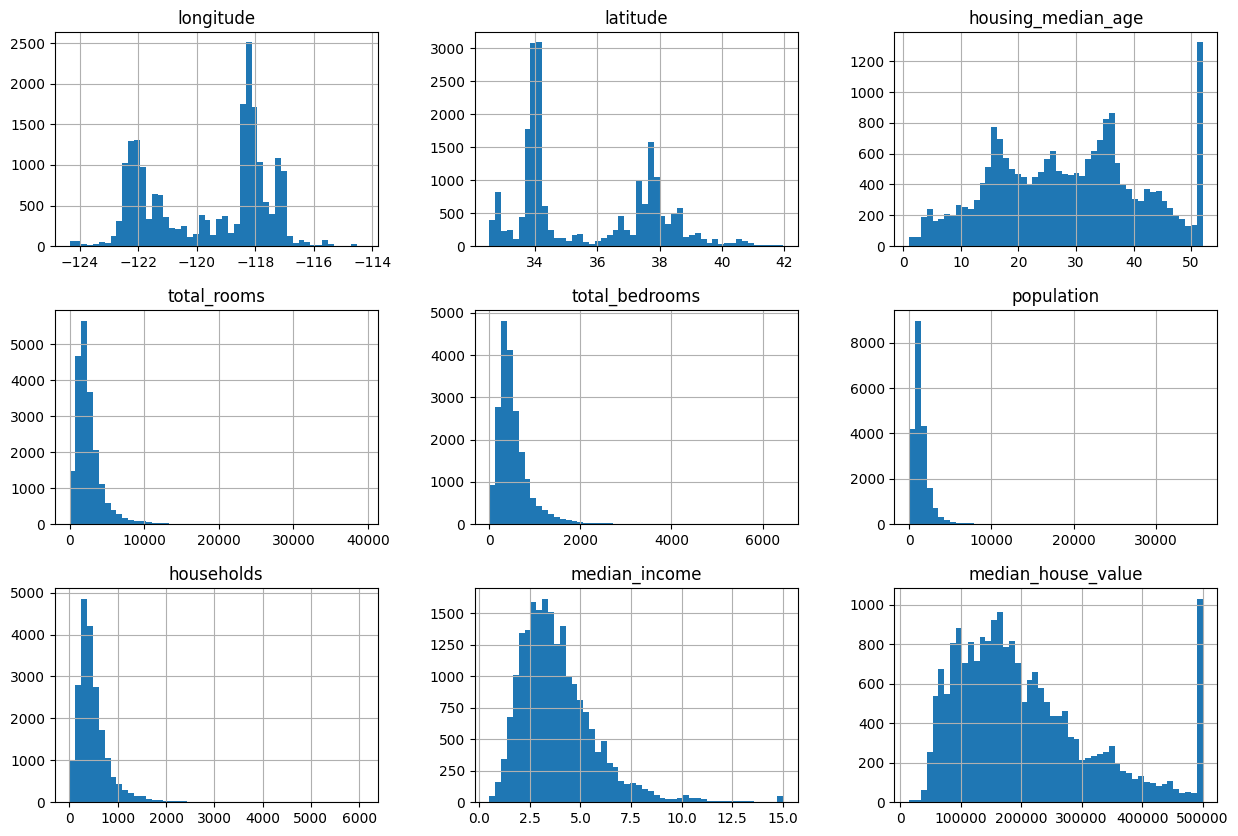

In [ ]:
# هنا نعرض التوزيع لجميع الأعمدة العددية باستخدام الرسوم البيانية (histograms)
df2.hist(bins=50, figsize=(15, 10))  #
# 'bins=50': تحديد عدد الأعمدة التي ستظهر في الرسم البياني.
# يعني إذا كانت البيانات تتراوح بين قيم معينة، سنقسمها إلى 50 فئة مختلفة.
# 'figsize=(15, 10)': تحديد حجم الشكل الذي سيظهر فيه الرسم البياني.
# الحجم هنا سيكون 15 بوصة عرضًا و 10 بوصة ارتفاعًا لسهولة قراءة التفاصيل.

plt.show()  # نعرض الشكل الذي يحتوي على الرسومات البيانية
# هذا السطر يعرض الشكل الناتج بعد أن تم رسم التوزيع لجميع الأعمدة العددية.


In [ ]:
# هنا نقوم بتحويل المتغير الفئوي 'ocean_proximity' إلى قيم رقمية باستخدام الدالة cat.codes
df2['ocean_proximity'] = df2['ocean_proximity'].astype('category').cat.codes

# 'ocean_proximity': هو العمود الذي يحتوي على فئات مختلفة مثل "NEAR BAY" أو "NEAR OCEAN" أو "INLAND".
# 'astype('category')': يقوم بتحويل العمود إلى نوع بيانات فئوي (categorical)، لأننا نحتاج إلى تحويل الفئات النصية إلى قيم رقمية.
# 'cat.codes': هنا نستخدم الدالة 'cat.codes' لتحويل الفئات النصية في العمود إلى قيم رقمية.

In [ ]:
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  int8   
dtypes: float64(9), int8(1)
memory usage: 1.4 MB


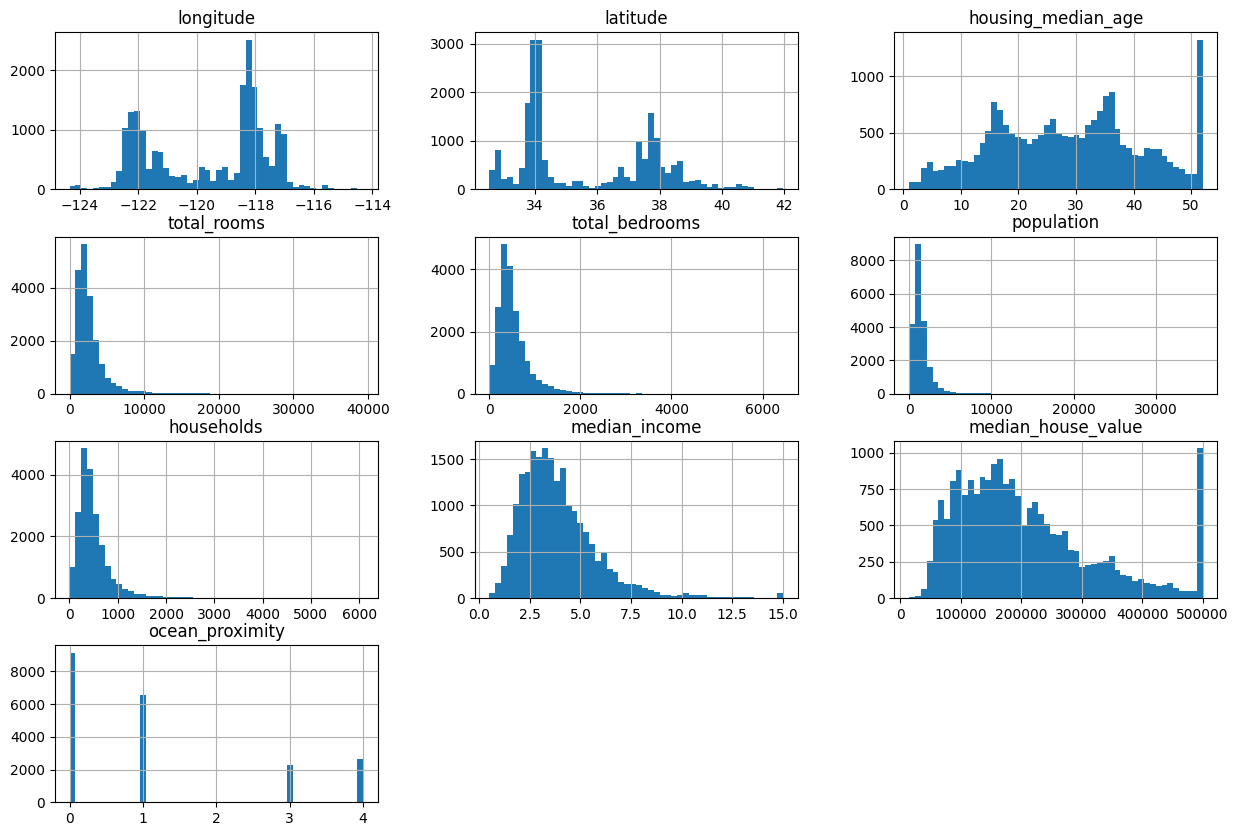

In [ ]:
# هنا نعرض التوزيع لجميع الأعمدة العددية باستخدام الرسوم البيانية (histograms)
df2.hist(bins=50, figsize=(15, 10))  # نحدد عدد الأعمدة (bins) وحجم الشكل
plt.show()  # نعرض الشكل


In [ ]:
# رسم توزيع الطول الجغرافي (Longitude)
# الأغلب من القيم تتراوح بين -124 و -118.
# التركيز أكبر في هالمنطقة، وفيه بعض النقاط اللي بعيدة عن هذا النطاق،
# وهذا يدل على وجود بيانات شاذة أو غير دقيقة.

# رسم توزيع العرض الجغرافي (Latitude)
# نلاحظ إن أغلب البيانات تتركز بين 34 و 38.
# يعني المناطق اللي تتركز فيها البيانات تكون في هالمنطقة، وخاصة بين 34 و 36.

# رسم توزيع إجمالي الغرف (Total Rooms)
# أغلب الوحدات السكنية تحتوي على عدد غرف بين 0 و 10,000 غرفة.
# وفيه عدد قليل من الوحدات اللي تحتوي على غرف كثيرة (أكثر من 20,000 غرفة)، لكنها قليلة مقارنة بالبقية.

# رسم توزيع إجمالي غرف النوم (Total Bedrooms)
# أكثر الوحدات السكنية تحتوي على أقل من 2000 غرفة نوم.
# فيه قلة من الوحدات اللي تحتوي على أكثر من 4000 غرفة نوم، بس هذي نادرة جدًا.

# رسم توزيع العمر المتوسط للسكن (Housing Median Age)
# أغلب المباني تتراوح أعمارها بين 10 و 50 سنة.
# فيه قمة واضحة عند عمر 50 سنة، هذا يعني فيه عدد قليل من المباني قديمة جدًا.

# رسم توزيع عدد السكان (Population)
# أغلب المناطق فيها عدد سكان أقل من 10,000 نسمة،
# مع بعض المناطق فيها أكثر من 30,000 نسمة، وهذا يدل على كثافة سكانية عالية في بعض الأماكن.

# رسم توزيع عدد الأسر (Households)
# أكثر المناطق تحتوي على عدد أسر أقل من 5000،
# وفيه مناطق تحتوي على أكثر من 10,000 أسرة، بس هذي قليلة مقارنة بالبقية.

# رسم توزيع الدخل المتوسط (Median Income)
# معظم الأسر عندها دخل متوسط بين 0 و 5,000 دولار.
# أما الأسر ذات الدخل العالي نادرة، وفيه قلة من الأسر دخلها أعلى من 6,000 دولار.

# رسم توزيع القيمة المتوسطة للمنازل (Median House Value)
# أغلب المنازل قيمتها أقل من 200,000 دولار.
# فيه عدد قليل من المنازل تتراوح قيمتها بين 300,000 و 500,000 دولار، وهذا يدل على وجود مناطق غالية أكثر.

# رسم توزيع قرب المحيط (Ocean Proximity)
# أغلب البيانات تكون إما قريبة جدًا أو بعيدة جدًا عن المحيط،
# التوزيع يكون في الفئات 0 (قريب) و 4 (بعيد)، مع قلة من المناطق في الفئات الأخرى.


In [ ]:
print("القيم المفقودة في الأعمدة:")
df2.isnull().sum()

القيم المفقودة في الأعمدة:


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
# ملء القيم المفقودة في عمود "total_bedrooms" باستخدام الوسيط
df2['total_bedrooms'] = df2['total_bedrooms'].fillna(df2['total_bedrooms'].median())

# أو يمكنك حذف الأعمدة التي تحتوي على قيم مفقودة
# df2.dropna(axis=1, inplace=True)  # حذف الأعمدة التي تحتوي على قيم مفقودة

# أو حذف السجلات التي تحتوي على قيم مفقودة
# df2.dropna(axis=0, inplace=True) حذف السجلات التي تحتوي على قيم مفقودة

# هذه الطريقة غالبًا ما تكون الأفضل في حالة البيانات العددية التي تحتوي على قيم مفقودة، لأنك تحافظ على حجم البيانات ولا تؤثر على توزيعها بشكل كبير

In [ ]:
df2.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


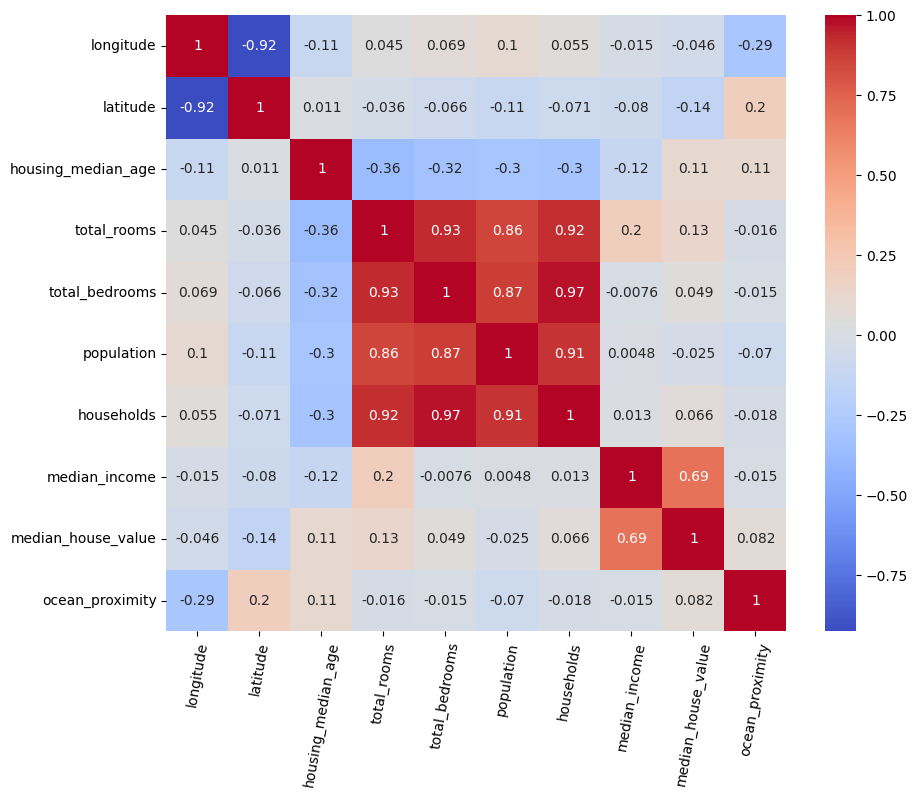

In [ ]:
# نعمل مصفوفة ارتباط بين المتغيرات المختلفة (correlation matrix)
correlation_matrix = df2.corr()

# أول شي، حددنا حجم الرسم بحيث يكون عرض 10 وارتفاع 8
plt.figure(figsize=(10, 8))

# هنا نرسم الخريطة الحرارية باستخدام المصفوفة اللي تحتوي على الارتباطات بين المتغيرات.
# وعرضنا القيم داخل المربعات علشان نقدر نعرف القيمة بالضبط.
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.xticks(rotation=80)
# annot=True: تعرض القيم داخل المربعات في الخريطة الحرارية.
# cmap='coolwarm': يستخدم مقياس الألوان "coolwarm" الذي يعرض القيم المنخفضة بالأزرق والقيم المرتفعة بالأحمر.
# في النهاية، نعرض الرسم اللي رسمناه علشان نشوفه.
plt.show()

# الشرح:
# - هذا الرسم اسمه "خريطة حرارية" (Heatmap)، وهو يوضح العلاقة بين مجموعة من المتغيرات (مثل الطول والعرض وعدد الغرف والحد الأدنى لقيمة المنزل وغيرها).
# - الألوان في الخريطة الحرارية تساعدنا نعرف إذا كانت العلاقة بين المتغيرات إيجابية أو سلبية:
#     - **اللون الأحمر** يعني هناك **علاقة إيجابية** قوية، يعني إذا زاد واحد من المتغيرات، يزيد الثاني بنفس الطريقة.
#     - **اللون الأزرق** يعني هناك **علاقة سلبية**، يعني إذا زاد واحد من المتغيرات، يقل الثاني.
#     - إذا كان اللون فاتح جدًا يعني الارتباط ضعيف أو ما فيه ارتباط بين المتغيرات.
# - الأرقام اللي في داخل المربعات هي **قيم الارتباط** بين المتغيرات.
#     - إذا كانت القيمة قريبة من **1**، يعني الارتباط قوي جدًا وإيجابي.
#     - إذا كانت القيمة قريبة من **-1**، يعني الارتباط قوي جدًا ولكن سالب (عكسي).
#     - إذا كانت القيمة قريبة من **0**، يعني ما فيه ارتباط قوي بين المتغيرات.

In [ ]:

# مثال بسيط:
# 1. "total_rooms" و "total_bedrooms":
# - القيمة 0.93: يعني إذا زاد عدد الغرف في البيت، غالبًا يزيد عدد غرف النوم بشكل كبير.
# - هذا يعني أن إذا كان عندك منزل كبير، بيكون فيه عدد أكبر من غرف النوم.

# 2. "longitude" و "ocean_proximity":
# - القيمة -0.29: هذا يعني إذا زاد الطول الجغرافي (longitude)، يقل قرب المحيط (ocean_proximity) شوية.
# - العلاقة هذي ضعيفة، يعني إذا كنت بعيد عن المحيط (أو على بعد طويل)، ما تأثر بشكل كبير.

# 3. "median_house_value" و "median_income":
# - القيمة 0.69: يعني كلما زاد الدخل المتوسط في المنطقة، غالبًا قيمة المنازل بتزيد.
# - مثلاً، المناطق اللي فيها دخل أعلى، غالبًا أسعار المنازل فيها تكون أغلى.

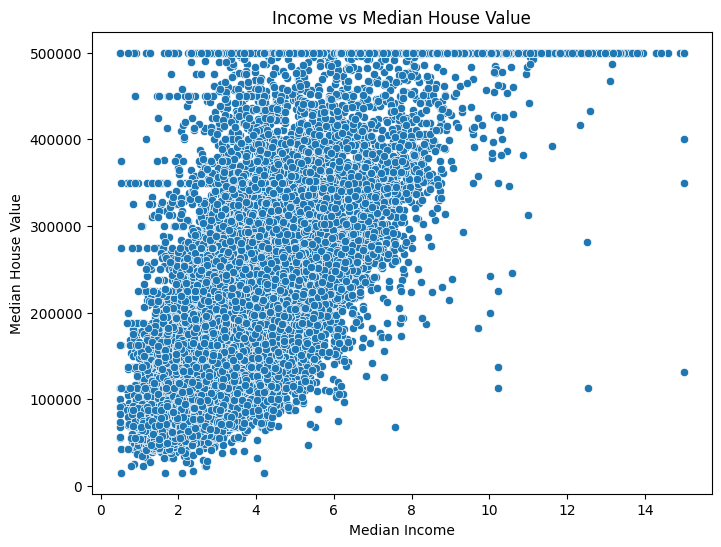

In [ ]:
# هنا نعرض علاقة الدخل الوسيط وسعر المنزل باستخدام scatter plot
# بنستخدم مكتبة seaborn لعرض العلاقة بين الدخل الوسيط وسعر المنزل

plt.figure(figsize=(8, 6))  # تحديد حجم الشكل (الرسم البياني)
sns.scatterplot(x=df2['median_income'], y=df2['median_house_value'])  # عرض الرسم البياني باستخدام scatter plot
plt.title('Income vs Median House Value')  # إضافة عنوان للرسم البياني
plt.xlabel('Median Income')  # تسمية المحور الأفقي (الدخل الوسيط)
plt.ylabel('Median House Value')  # تسمية المحور الرأسي (سعر المنزل الوسيط)
plt.show()  # عرض الرسم البياني


In [ ]:
# هذا الرسم البياني المنتشر (scatter plot) يوضح لنا العلاقة بين الدخل الوسيط (Median Income) وسعر المنزل الوسيط (Median House Value).

# المحور الأفقي (X-axis) يمثل الدخل الوسيط اللي يترواح بين 0 و 15 تقريبًا.
# - يعني إذا كان الدخل الوسيط قريب من صفر، فهذا يدل على دخل ضعيف.
# - وإذا كان الدخل الوسيط 15، يعني دخل عالي جدًا.

# أما المحور الرأسي (Y-axis) فهو يمثل سعر المنزل الوسيط اللي يتراوح من 0 إلى 500,000 تقريبًا.
# - إذا كانت قيمة المنزل حوالي 100,000، فهذا يعني أن المنزل رخيص نوعًا ما.
# - وإذا كانت قيمة المنزل تصل إلى 500,000 أو أكثر، فهذا يدل على أن المنزل قيمته عالية.

# تلاحظون أن في الرسم فيه اتجاه تصاعدي:
# كلما زاد الدخل الوسيط (من 0 إلى 15)، زادت قيمة المنزل (من 100,000 إلى 500,000).
# يعني بشكل عام، الزيادة في الدخل بتؤدي لزيادة في قيمة المنزل.

# ومن الملاحظ أن فيه تباين واضح:
# - في الجزء السفلي من الرسم (الدخل المنخفض)، تلقى أسعار المنازل منخفضة.
# - في الجزء العلوي من الرسم (الدخل المرتفع)، تلقى أسعار المنازل مرتفعة.
# هذا يعني أن فيه اختلاف كبير بين الدخل وسعر المنزل.

# الرسم البياني هذا يعطينا فكرة واضحة عن كيف أن الدخل يؤثر بشكل كبير على أسعار المنازل، وهو يساعد في فهم العلاقة بين العوامل هذه.



In [ ]:
# الهدف من الكود هو تقسيم البيانات إلى جزئين:
# - مجموعة التدريب: 80% من البيانات، تستخدم لتعليم النموذج الأنماط والارتباطات بين المدخلات (الميزات) والمخرجات (الهدف، مثل "القيمة المتوسطة للمنزل").
# - مجموعة الاختبار: 20% من البيانات، تستخدم لتقييم أداء النموذج بعد التدريب، عن طريق مقارنة التنبؤات بالقيم الحقيقية.
from sklearn.model_selection import train_test_split


# X: المدخلات (الميزات) وهي بياناتنا ما عدا عمود "median_house_value".
# y: المخرجات (الهدف) وهي القيم الفعلية التي نريد التنبؤ بها، مثل أسعار المنازل.
X = df2.drop('median_house_value', axis=1)
y = df2['median_house_value']

# هنا نقسم البيانات:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# استخدمنا دالة train_test_split من مكتبة sklearn لتقسيم البيانات إلى قسمين:
# - 80% للتدريب (X_train, y_train)
# - 20% للاختبار (X_test, y_test)

# نعرض حجم مجموعة التدريب والاختبار:
print(f"حجم مجموعة التدريب: {X_train.shape[0]} أمثلة")  # هنا نعرض عدد الأمثلة في مجموعة التدريب
print(f"حجم مجموعة الاختبار: {X_test.shape[0]} أمثلة")  # هنا نعرض عدد الأمثلة في مجموعة الاختبار



# النتيجة:
# حجم مجموعة التدريب: 16512 يعني أن 80% من البيانات تم استخدامها لتدريب النموذج.
# حجم مجموعة الاختبار: 4128 يعني أن 20% من البيانات تم استخدامها لاختبار النموذج بعد التدريب.

# الهدف هو تدريب النموذج على 80% من البيانات ليتعلم الأنماط، ثم اختباره على 20% المتبقية للتأكد من قدرته على التنبؤ بشكل دقيق على بيانات جديدة.

حجم مجموعة التدريب: 16512 أمثلة
حجم مجموعة الاختبار: 4128 أمثلة
